# **Loading the data**

In [1]:
import os
import itertools
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import seaborn as sns
import numpy as np
import shutil
from glob import glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, Model
from sklearn.model_selection import StratifiedKFold
from skimage import exposure
import pickle
import random
import sys
import gc

In [2]:
K = 5
EPOCHS = 30
BATCH_SIZE = 32
LR = 1e-4
Class_Names = ["Glioma", "Meningioma", "Pituitary"]
all_experiments = {}

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
base_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή"

In [5]:
sys.path.append('/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή')
from PreProcessing_Script import dataset_preparation

In [6]:
cnn_root_dir = "/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model"

def create_experiment_folders(experiment_name):
    experiment_dir = os.path.join(cnn_root_dir, experiment_name)
    results_dir = os.path.join(experiment_dir, "results")
    images_dir = os.path.join(results_dir, "images")
    models_dir = os.path.join(results_dir, "models")
    report_dir = os.path.join(results_dir, "report")

    os.makedirs(images_dir, exist_ok=True)
    os.makedirs(models_dir, exist_ok=True)
    os.makedirs(report_dir, exist_ok=True)

    return {
        "experiment_dir": experiment_dir,
        "results_dir": results_dir,
        "images_dir": images_dir,
        "models_dir": models_dir,
        "report_dir": report_dir
    }

combined_roc_cnn_path = os.path.join(cnn_root_dir, "combined_roc_cnn.png")
cnn_experiments_path  = os.path.join(cnn_root_dir, "cnn_experiments.pkl")

In [7]:
x_train_val_raw = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/x_train_val_raw.pkl","rb"))
x_test_raw      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/x_test_raw.pkl","rb"))
y_train_val_int = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/y_train_val_int.pkl","rb"))
y_test_int      = pickle.load(open("/content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/pickle_data/y_test_int.pkl","rb"))

In [8]:
input_shape = (x_train_val_raw.shape[1], x_train_val_raw.shape[2])

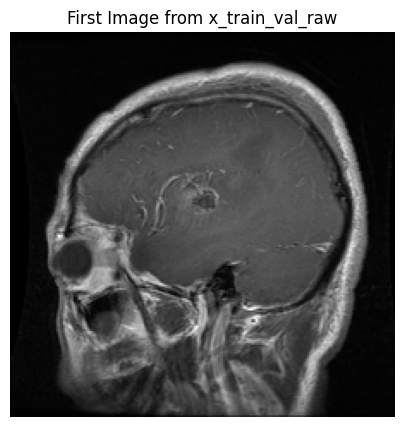

In [9]:
# Select the first image from x_train_val_raw
# Assuming x_train_val_raw is a NumPy array of images
image_to_display = x_train_val_raw[0]

plt.figure(figsize=(5, 5))
plt.imshow(image_to_display, cmap='gray')
plt.title('First Image from x_train_val_raw')
plt.axis('off') # Hide axes ticks and labels
plt.show()

# Saving

In [10]:
def get_save_paths(model_or_experiment_name):
    if isinstance(model_or_experiment_name, str):
        experiment_name = model_or_experiment_name
    else:
        experiment_name = model_or_experiment_name.experiment_name

    folders = create_experiment_folders(experiment_name)

    paths = {
        "model": os.path.join(folders["models_dir"], f"{experiment_name}.keras"),
        "train_loss": os.path.join(folders["images_dir"], f"{experiment_name}_train_loss.png"),
        "train_accuracy": os.path.join(folders["images_dir"], f"{experiment_name}_train_accuracy.png"),
        "confusion_matrix": os.path.join(folders["images_dir"], f"{experiment_name}_confusion_matrix.png"),
        "roc_curve": os.path.join(folders["images_dir"], f"{experiment_name}_roc_curve.png"),
        "auc_report": os.path.join(folders["report_dir"], f"{experiment_name}_auc_report.txt"),
        "classification_report": os.path.join(folders["report_dir"], f"{experiment_name}_classification_report.txt"),
        "confusion_matrix_txt": os.path.join(folders["report_dir"], f"{experiment_name}_confusion_matrix.txt"),
        "kfold_metrics": os.path.join(folders["report_dir"], f"{experiment_name}_kfold_metrics.txt"),
        "kfold_loss": os.path.join(folders["images_dir"], f"{experiment_name}_kfold_loss.png"),
        "kfold_accuracy": os.path.join(folders["images_dir"], f"{experiment_name}_kfold_accuracy.png"),
        "roc_raw_data": os.path.join(folders["report_dir"], f"{experiment_name}_roc_raw_data")
    }

    return paths

# **Plots**

In [11]:
def acc_and_loss(history, model_experiment_name, save_paths=None):
  hist = history.history

  epochs_acc = np.arange(1, len(hist["accuracy"])+1)
  epochs_loss = np.arange(1, len(hist["loss"])+1)

  fig_acc, ax_acc = plt.subplots(figsize=(10,5), dpi = 120)
  ax_acc.plot(
      epochs_acc,
      hist["accuracy"],
      label = "Training Accuracy",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_accuracy" in hist:
    ax_acc.plot(
        epochs_acc,
        hist["val_accuracy"],
        label = "Validation Accuracy",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_acc.set_title(f"{model_experiment_name} - Accuracy")
  ax_acc.set_xlabel("Epochs")
  ax_acc.set_ylabel("Accuracy")
  ax_acc.grid(True, alpha = 0.3)
  ax_acc.legend()
  fig_acc.tight_layout()

  if save_paths is not None and "train_accuracy" in save_paths:
    fig_acc.savefig(save_paths["train_accuracy"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_acc)

  fig_loss, ax_loss = plt.subplots(figsize=(10,5), dpi = 120)
  ax_loss.plot(
      epochs_loss,
      hist["loss"],
      label = "Training Loss",
      linewidth = 2,
      marker = 'o',
      markersize = 5
  )

  if "val_loss" in hist:
    ax_loss.plot(
        epochs_loss,
        hist["val_loss"],
        label = "Validation Loss",
        linewidth = 2,
        marker = 's',
        markersize = 5
    )

  ax_loss.set_title(f"{model_experiment_name} - Loss")
  ax_loss.set_xlabel("Epochs")
  ax_loss.set_ylabel("Loss")
  ax_loss.grid(True, alpha = 0.3)
  ax_loss.legend()
  fig_loss.tight_layout()

  if save_paths is not None and "train_loss" in save_paths:
    fig_loss.savefig(save_paths["train_loss"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_loss)

  print('Loss:')
  print('  - loss [training dataset]: {:.3f}'.format(hist['loss'][-1]))
  if 'val_loss' in hist:
      print('  - loss [validation dataset]: {:.3f}'.format(hist['val_loss'][-1]))

  print('')
  print('Accuracy:')
  print('  - accuracy [training dataset]: {:.2f}%'.format(100 * hist['accuracy'][-1]))
  if 'val_accuracy' in hist:
      print('  - accuracy [validation dataset]: {:.2f}%'.format(100 * hist['val_accuracy'][-1]))

  return fig_acc, fig_loss

In [12]:
def plot_kfold(histories, title_prefix='', save_paths = None):

  min_len = min([len(h['loss']) for h in histories])

  train_loss = np.array([h['loss'][:min_len] for h in histories])
  val_loss = np.array([h['val_loss'][:min_len] for h in histories])

  train_acc = np.array([h['accuracy'][:min_len] for h in histories])
  val_acc = np.array([h['val_accuracy'][:min_len] for h in histories])

  epochs = np.arange(1, min_len+1)

  # Loss plot
  fig_loss, ax_loss = plt.subplots(figsize=(10, 5), dpi=120)
  ax_loss.plot(epochs, train_loss.mean(axis=0), label='Training Loss')
  ax_loss.plot(epochs, val_loss.mean(axis=0), label='Validation Loss')
  ax_loss.set_title(f'{title_prefix} - KFold Loss')
  ax_loss.set_xlabel('Epochs')
  ax_loss.set_ylabel('Loss')
  ax_loss.legend()
  ax_loss.grid(True, alpha=0.3)
  fig_loss.tight_layout()

  if save_paths is not None and "kfold_loss" in save_paths:
    fig_loss.savefig(save_paths["kfold_loss"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_loss)

  # Accuracy plot
  fig_acc, ax_acc = plt.subplots(figsize=(10, 5), dpi=120)
  ax_acc.plot(epochs, train_acc.mean(axis=0), label='Training Accuracy')
  ax_acc.plot(epochs, val_acc.mean(axis=0), label='Validation Accuracy')
  ax_acc.set_title(f'{title_prefix} - KFold Accuracy')
  ax_acc.set_xlabel('Epochs')
  ax_acc.set_ylabel('Accuracy')
  ax_acc.legend()
  ax_acc.grid(True, alpha=0.3)
  fig_acc.tight_layout()

  if save_paths is not None and "kfold_accuracy" in save_paths:
    fig_acc.savefig(save_paths["kfold_accuracy"], dpi=300, bbox_inches='tight')

  plt.show()
  plt.close(fig_acc)

In [13]:
def plot_confusion_matrix(cm, Class_Names, save_path=None):

  plt.figure()
  plt.colorbar(plt.imshow(cm))
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.xticks(np.arange(len(Class_Names)), Class_Names, rotation=45)
  plt.yticks(np.arange(len(Class_Names)), Class_Names)

  for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
      plt.text(j, i, str(cm[i, j]), ha="center", va="center")

  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

In [14]:
def plot_roc_auc(y_true_int, y_prob, class_names, save_path=None):
  n_classes = len(class_names)

  y_true_bin = label_binarize(y_true_int, classes=np.arange(n_classes))

  fpr = dict()
  tpr = dict()
  roc_auc = dict()

  plt.figure(figsize=(10, 10), dpi=120)

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

    plt.plot(
        fpr[i],
        tpr[i],
        linewidth=2,
        label=f"{class_names[i]} (AUC = {roc_auc[i]:.3f})")

  plt.plot([0,1], [0,1], 'k--', linewidth=1)

  plt.xlabel("False Positive Rate")
  plt.ylabel("True Positive Rate")
  plt.title("ROC Curve (One-vs-Rest)")
  plt.legend(loc="lower right")
  plt.grid(alpha=0.3)
  plt.tight_layout()

  if save_path is not None:
    plt.savefig(save_path, dpi=300, bbox_inches='tight')

  plt.show()

  macro_auc = np.mean(list(roc_auc.values()))
  print("\nAUC per Class: ")
  for i in range(n_classes):
    print(f"{class_names[i]}: {roc_auc[i]:.4f}")
  print(f"Macro AUC: {macro_auc:.4f}")

  return roc_auc, macro_auc


In [15]:
def plot_combined_roc(experiments, class_names, save_path=None):
    n_classes = len(class_names)

    plt.figure(figsize=(10, 10), dpi=120)

    for exp_name, exp_data in experiments.items():
        data = np.load(exp_data["roc_raw_data"])

        all_fpr  = np.linspace(0, 1, 100)
        mean_tpr = np.zeros_like(all_fpr)

        for i in range(n_classes):
            fpr = data[f"fpr_{i}"]
            tpr = data[f"tpr_{i}"]
            mean_tpr += np.interp(all_fpr, fpr, tpr)

        mean_tpr /= n_classes
        macro_auc = exp_data["macro_auc"]

        plt.plot(all_fpr, mean_tpr, linewidth=2,
                 label=f"{exp_name} (Macro AUC = {macro_auc:.3f})")

    plt.plot([0, 1], [0, 1], 'k--', linewidth=1)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve Comparison (Macro Average)")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.show()

# Compile Function

In [16]:
def compile_model(model, lr):
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=["accuracy"]
    )
    return model

# CNN Models

## Base CNN Model

In [17]:
def cnn_model_base(use_augmentation = None, model_key="cnn"):

  inputs = layers.Input(shape=(224, 224, 1))

  x = inputs

  if use_augmentation:
    augmentation = build_augmentation()
    x = augmentation(x)

  x = layers.Conv2D(filters = 16, kernel_size = 3, padding = "same", activation = "relu")(x)
  x = layers.Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 16, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)

  x = layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 32, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)

  x = layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 64, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)

  x = layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 128, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Conv2D(filters = 256, kernel_size = 3, padding = 'same', activation = 'relu')(x)
  x = layers.Dropout(0.2)(x)
  x = layers.MaxPooling2D(pool_size = 2)(x)
  x = layers.GlobalMaxPooling2D()(x)

  outputs = layers.Dense(3, activation = 'softmax')(x)

  model_cnn_base = tf.keras.Model(inputs = inputs, outputs = outputs, name=model_key)

  model_cnn_base.model_key = "cnn"
  model_cnn_base.experiment_name = model_key

  return model_cnn_base

model_cnn_base = cnn_model_base()

initial_weight = model_cnn_base.get_weights()

In [18]:
model_cnn_base.summary()

Model: "cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 16)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 224, 224, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 224, 224, 16)   │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 224, 224, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 112, 112, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 112, 112, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling2d            │ (None, 256)            │             0 │
│ (GlobalMaxPooling2D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 637,667 (2.43 MB)

 Trainable params: 637,667 (2.43 MB)

 Non-trainable params: 0 (0.00 B)

## Data Augmentation

In [19]:
def build_augmentation():
  return tf.keras.Sequential([
      layers.RandomRotation(0.01),
      layers.RandomTranslation(height_factor=0.005, width_factor=0.005),
      layers.RandomZoom(0.01),
  ], name="data_augmentation")

## Builder

In [20]:
def build_model(cfg):
  model = cfg["builder"]()
  model.model_key = cfg["model_key"]
  model.experiment_name = cfg["experiment_name"]
  return model

# List Of Experiments

In [21]:
EXPERIMENTS = {
    "cnn_base": {
        "builder": lambda: cnn_model_base(
            use_augmentation=False,
            model_key="cnn_base"
        ),
        "model_key": "cnn",
        "experiment_name": "cnn_base",
        "use_augmentation": False
    },
    "cnn_aug": {
        "builder": lambda: cnn_model_base(
            use_augmentation=True,
            model_key="cnn_aug"
        ),
        "model_key": "cnn",
        "experiment_name": "cnn_aug",
        "use_augmentation": True
    }
}

# **Dataset Preparation**

In [22]:
def make_ds(X, y, batch_size=32, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))

    if training:
      ds = ds.shuffle(len(X), seed=42, reshuffle_each_iteration=True)

    ds = ds.batch(batch_size)

    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

# Functions for K-Fold, Training and Evaluation

In [23]:
def kfold(x_raw, y, cfg, K, BATCH_SIZE, LR, EPOCHS):
  skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

  fold_metrics = []
  fold_histories = []

  for fold, (train_idx, val_idx) in enumerate(skf.split(x_raw, y), start=1):
    print(f"\n=== {cfg["experiment_name"]} / Fold {fold}/{K} ===")

    x_tr_raw = x_raw[train_idx]
    x_va_raw = x_raw[val_idx]
    y_tr = y[train_idx]
    y_va = y[val_idx]

    x_tr, x_va = dataset_preparation(
        cfg["model_key"],
        x_raw[train_idx],
        x_raw[val_idx]
    )

    x_tr_4D = np.expand_dims(x_tr, axis=-1)
    x_va_4D = np.expand_dims(x_va, axis=-1)

    train_ds = make_ds(x_tr_4D, y_tr, batch_size=BATCH_SIZE, training=True)
    val_ds = make_ds(x_va_4D, y_va, batch_size=BATCH_SIZE, training=False)

    fold_model = build_model(cfg)
    fold_model = compile_model(fold_model, lr=LR)

    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=5,
            restore_best_weights=True,
            min_delta=0.001
        )
    ]

    history = fold_model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        verbose = 1,
        callbacks=callbacks
    )

    val_loss, val_acc = fold_model.evaluate(val_ds, verbose = 0)

    fold_metrics.append({
        "fold": fold,
        "val_loss": val_loss,
        "val_acc": val_acc
    })

    fold_histories.append({
        "loss": history.history["loss"],
        "val_loss": history.history["val_loss"],
        "accuracy": history.history["accuracy"],
        "val_accuracy": history.history["val_accuracy"]
    })

    del x_tr, y_tr, x_va, y_va, train_ds, val_ds, fold_model, history, x_tr_4D, x_va_4D
    gc.collect()
    tf.keras.backend.clear_session()

  return fold_metrics, fold_histories

In [24]:
def train_test(cfg, save_model = True):

  model = build_model(cfg)
  save_paths = get_save_paths(model)

  x_train_raw, x_val_raw, y_train_int, y_val_int = train_test_split(
      x_train_val_raw,
      y_train_val_int,
      test_size=0.2,
      random_state=42,
      stratify=y_train_val_int
  )

  x_train_pp, x_val_pp = dataset_preparation(cfg["model_key"],
                                              x_train_raw,
                                              x_val_raw)
  _, x_test_pp = dataset_preparation(cfg["model_key"],
                                     x_train_val_raw[:1],
                                     x_test_raw)

  x_train_pp_4D = np.expand_dims(x_train_pp, axis=-1)
  x_val_pp_4D = np.expand_dims(x_val_pp, axis=-1)
  x_test_pp_4D = np.expand_dims(x_test_pp, axis=-1)

  train_ds = make_ds(x_train_pp_4D, y_train_int, batch_size=BATCH_SIZE, training=True)
  val_ds = make_ds(x_val_pp_4D, y_val_int, batch_size = BATCH_SIZE, training=False)
  test_ds = make_ds(x_test_pp_4D, y_test_int, batch_size=BATCH_SIZE, training=False)

  model.set_weights(initial_weight)

  model = compile_model(model, lr=LR)

  callbacks = [
      tf.keras.callbacks.EarlyStopping(
          monitor='val_accuracy',
          patience=5,
          restore_best_weights=True,
          min_delta=0.001)
  ]

  history = model.fit(
      train_ds,
      validation_data=val_ds,
      epochs=EPOCHS,
      verbose = 1,
      callbacks = callbacks
  )

  if save_model:
    model.save(save_paths["model"])

  test_loss, test_accuracy = model.evaluate(test_ds, verbose = 0)

  y_prob = model.predict(test_ds, verbose=0)
  y_pred = np.argmax(y_prob, axis=1)

  cm = confusion_matrix(y_test_int, y_pred)

  print("Test Loss: ", float(test_loss))
  print("Test Accuracy: ", float(test_accuracy))

  report = classification_report(
      y_test_int,
      y_pred,
      target_names=Class_Names
  )

  print("Classification Report:")
  print(report)

  roc_auc_dict, macro_auc = plot_roc_auc(
      y_test_int,
      y_prob,
      Class_Names,
      save_paths["roc_curve"]
  )

  y_true_bin = label_binarize(y_test_int, classes=np.arange(len(Class_Names)))
  save_dict  = {}
  for i in range(len(Class_Names)):
    fpr_i, tpr_i, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    save_dict[f"fpr_{i}"] = fpr_i
    save_dict[f"tpr_{i}"] = tpr_i
  np.savez(save_paths["roc_raw_data"], **save_dict)

  with open(save_paths["classification_report"], "w") as f:
    f.write(report)
    f.write("\n")
    f.write(f"Test Loss: {float(test_loss):.4f}\n")
    f.write(f"Test Accuracy: {float(test_accuracy):.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  with open(save_paths["confusion_matrix_txt"], "w") as f:
    f.write(str(cm))

  with open(save_paths["auc_report"], "w") as f:
    for i, class_name in enumerate(Class_Names):
      f.write(f"{class_name}: AUC = {roc_auc_dict[i]:.4f}\n")
    f.write(f"Macro AUC: {macro_auc:.4f}\n")

  plot_confusion_matrix(cm, Class_Names, save_paths["confusion_matrix"])

  acc_and_loss(history, model.experiment_name, save_paths=save_paths)

  del x_train_raw, x_val_raw, x_train_pp, x_val_pp, x_test_pp, x_train_pp_4D, x_val_pp_4D, x_test_pp_4D, train_ds, val_ds, test_ds
  gc.collect()

  return model, history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, save_paths["roc_raw_data"]

# Base CNN

In [25]:
cfg_base = EXPERIMENTS["cnn_base"]

## K-Fold(K=5)

In [26]:
base_metrics, base_histories = kfold(x_raw=x_train_val_raw,
                                     y=y_train_val_int,
                                     cfg = cfg_base,
                                     K=K,
                                     BATCH_SIZE = BATCH_SIZE,
                                     LR = LR,
                                     EPOCHS = EPOCHS)


=== cnn_base / Fold 1/5 ===
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 43s 361ms/step - accuracy: 0.4730 - loss: 1.0574 - val_accuracy: 0.6232 - val_loss: 1.0489
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 125ms/step - accuracy: 0.6133 - loss: 0.8811 - val_accuracy: 0.6415 - val_loss: 0.8195
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 127ms/step - accuracy: 0.6602 - loss: 0.7438 - val_accuracy: 0.7189 - val_loss: 0.7963
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 128ms/step - accuracy: 0.7122 - loss: 0.6791 - val_accuracy: 0.7128 - val_loss: 0.7677
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.7388 - loss: 0.5848 - val_accuracy: 0.7088 - val_loss: 0.6689
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 132ms/step - accuracy: 0.7832 - loss: 0.5165 - val_accuracy: 0.7556 - val_loss: 0.5991
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 135ms/step - accuracy: 0.7959 - loss: 0.4841 - val_accuracy: 0.7984 - val_loss: 0.5658
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 137

In [27]:
base_accuracy = [m["val_acc"] for m in base_metrics]
base_losses = [m["val_loss"] for m in base_metrics]

print("Fold Accuracies:", base_accuracy)
print("Mean Accuracy :", np.mean(base_accuracy))
print("Std Accuracy  :", np.std(base_accuracy))
print("Mean Loss     :", np.mean(base_losses))
print("Std Loss      :", np.std(base_losses))

Fold Accuracies: [0.8574337959289551, 0.8775510191917419, 0.8530611991882324, 0.8163265585899353, 0.7877551317214966]
Mean Accuracy : 0.8384255409240723
Std Accuracy  : 0.03213152560894297
Mean Loss     : 0.4810660481452942
Std Loss      : 0.0911972321538966


In [28]:
save_paths = get_save_paths(cfg_base["experiment_name"])

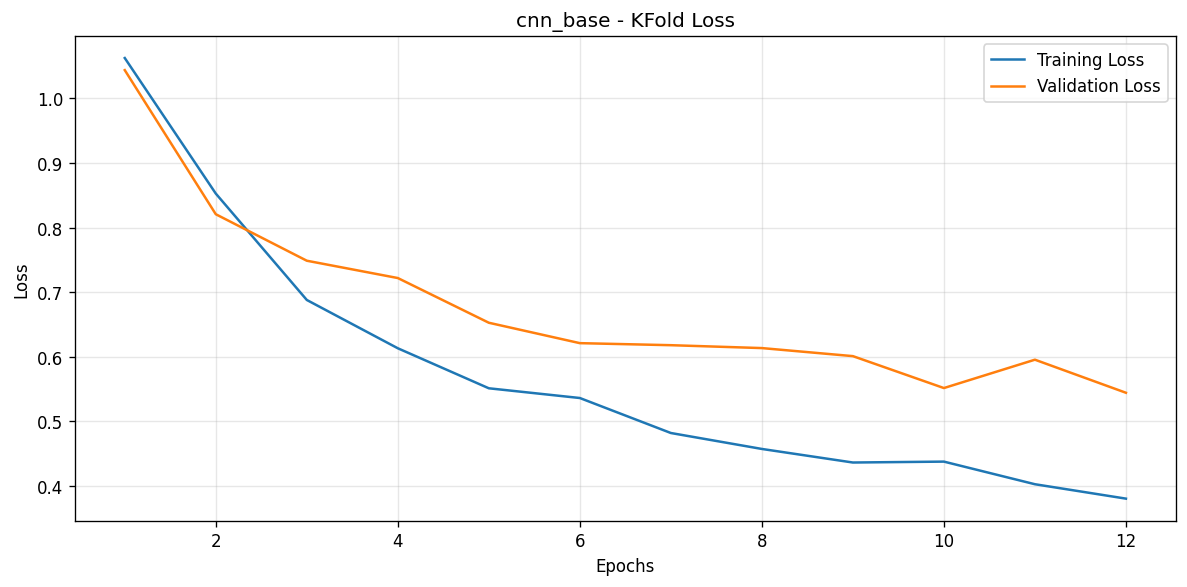

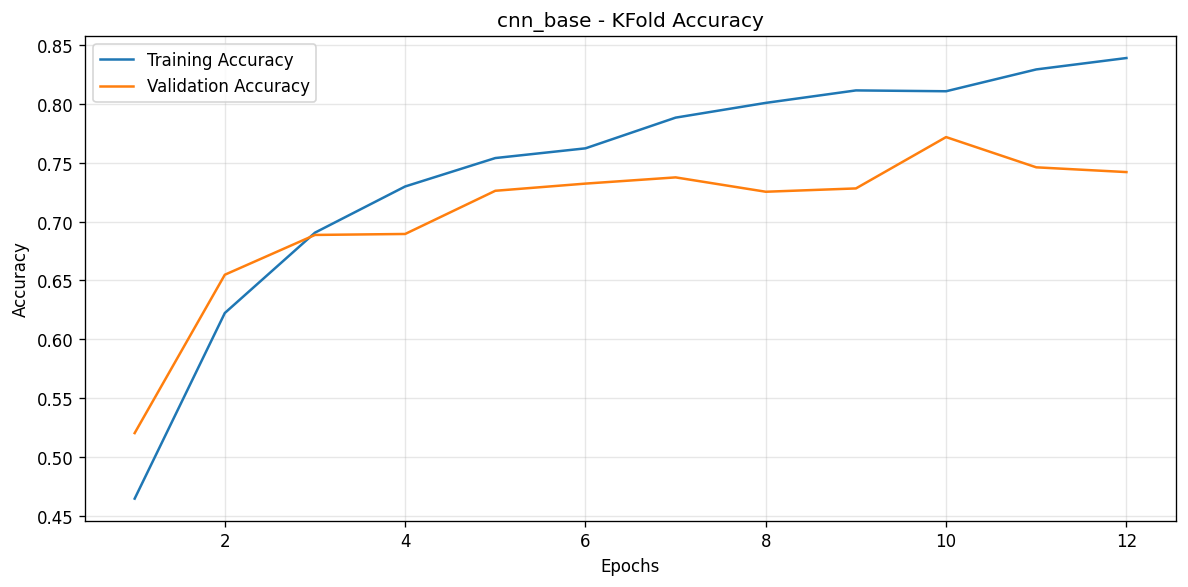

In [29]:
plot_kfold(
    base_histories,
    title_prefix=cfg_base["experiment_name"],
    save_paths=save_paths
)

In [30]:
with open(save_paths["kfold_metrics"], "w") as f:
    for row in base_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(base_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(base_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(base_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(base_losses):.4f}\n")

In [31]:
del base_metrics
del base_histories
gc.collect()

14173

## Training + Evaluation

Using preprocessing: baseline
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 27s 276ms/step - accuracy: 0.4628 - loss: 1.0548 - val_accuracy: 0.5886 - val_loss: 1.0394
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 26s 133ms/step - accuracy: 0.6352 - loss: 0.8478 - val_accuracy: 0.6721 - val_loss: 0.8823
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.6571 - loss: 0.7371 - val_accuracy: 0.7434 - val_loss: 0.8090
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 9s 139ms/step - accuracy: 0.7107 - loss: 0.6368 - val_accuracy: 0.7597 - val_loss: 0.7058
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.7480 - loss: 0.5751 - val_accuracy: 0.7393 - val_loss: 0.6835
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 133ms/step - accuracy: 0.7551 - loss: 0.5481 - val_accuracy: 0.7780 - val_loss: 0.6310
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.7520 - loss: 0.5372 - val_accuracy: 0.7413 - val_loss: 0.6248
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 8s 1

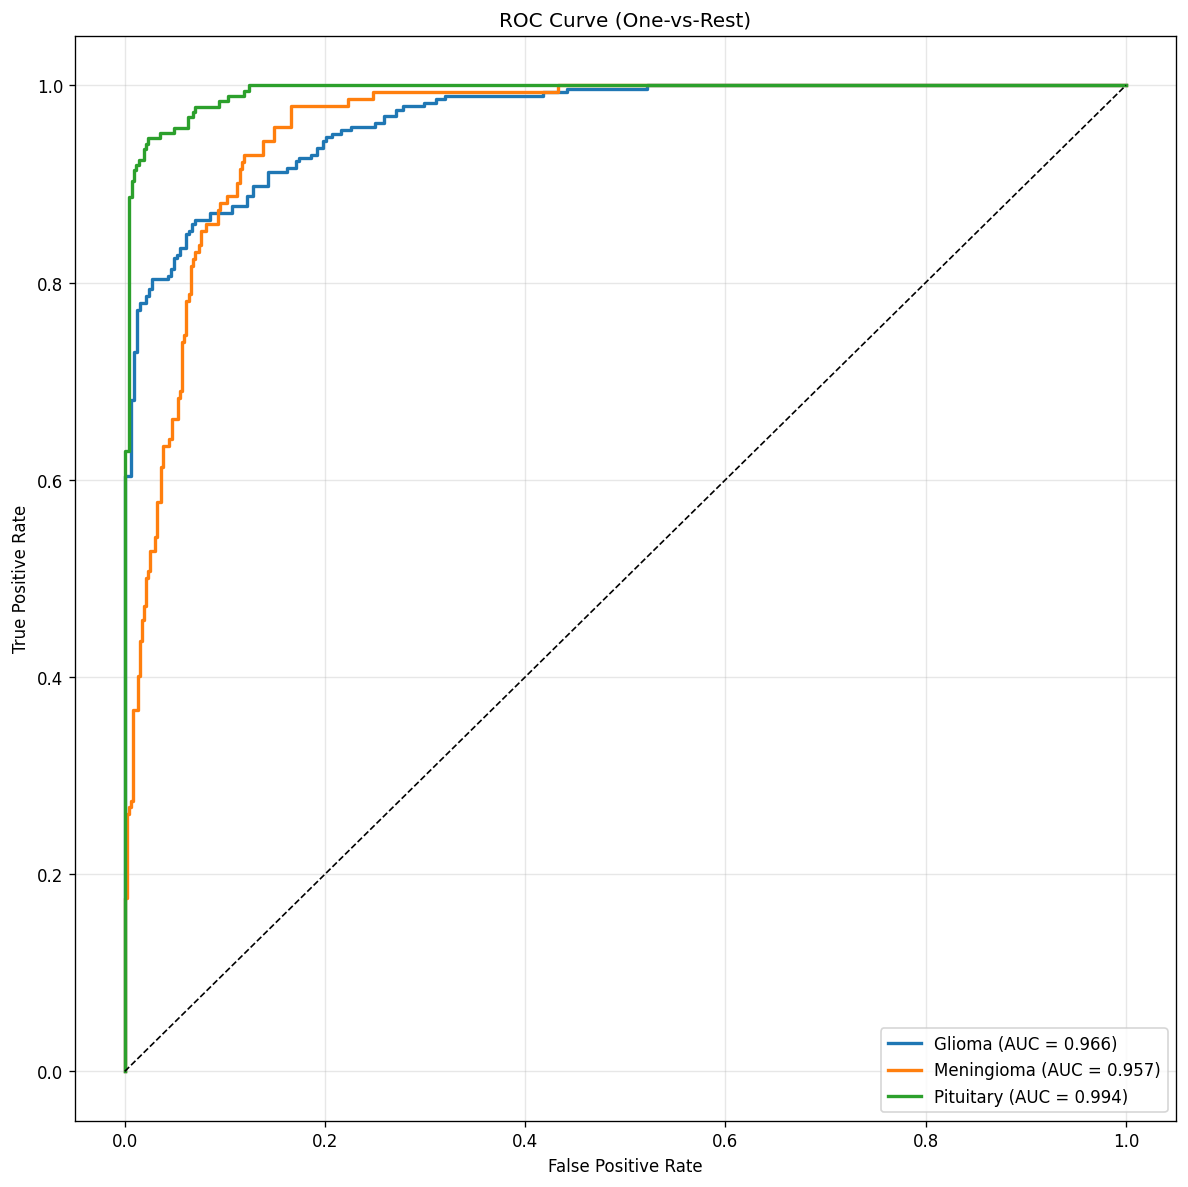


AUC per Class: 
Glioma: 0.9661
Meningioma: 0.9573
Pituitary: 0.9938
Macro AUC: 0.9724


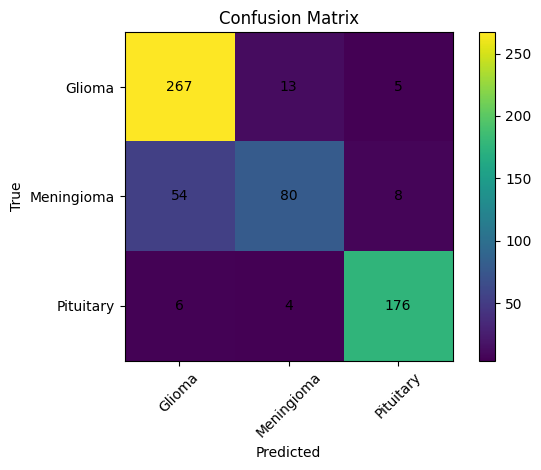

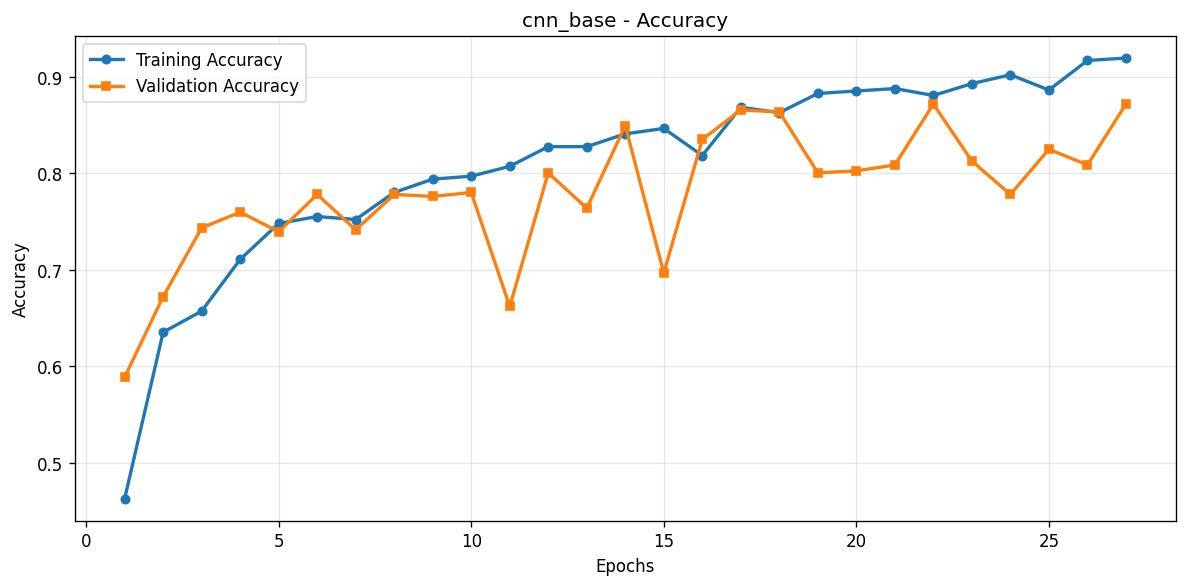

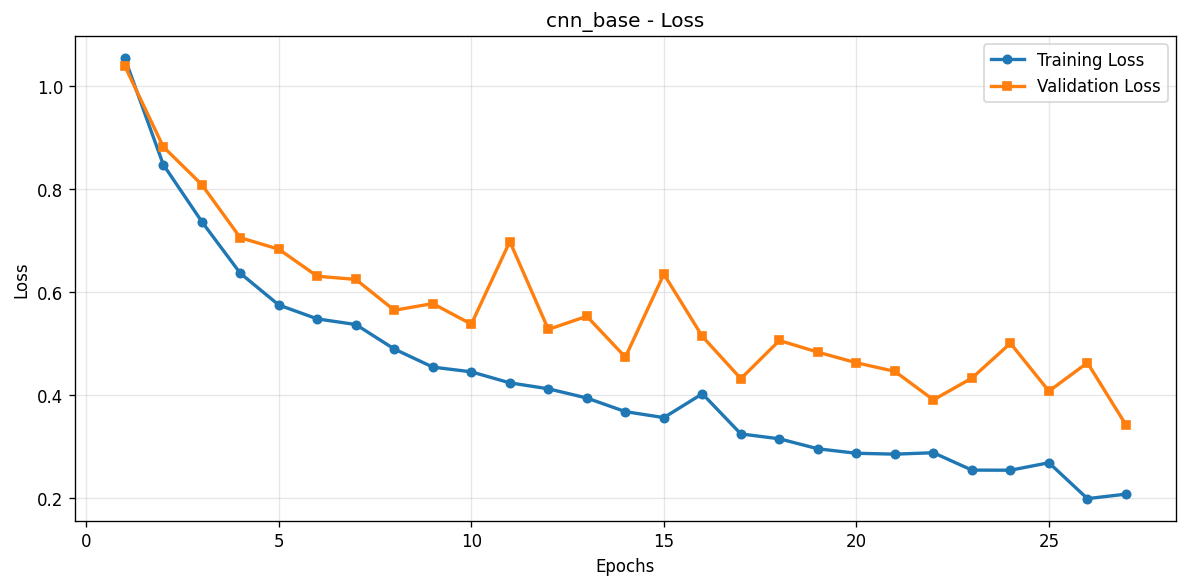

Loss:
  - loss [training dataset]: 0.208
  - loss [validation dataset]: 0.342

Accuracy:
  - accuracy [training dataset]: 91.94%
  - accuracy [validation dataset]: 87.17%


In [32]:
final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, roc_raw_data_path = train_test(
    cfg = cfg_base,
    save_model = True
)

all_experiments["CNN Base"] = {
    "macro_auc":    macro_auc,
    "roc_raw_data": roc_raw_data_path + ".npz"
}

In [33]:
del final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, cfg_base, roc_raw_data_path, save_paths
gc.collect()

10016

In [34]:
tf.keras.backend.clear_session()

# Base CNN with Augmentation

In [35]:
cfg_aug = EXPERIMENTS["cnn_aug"]

## K-Fold(K=5)

In [36]:
aug_metrics, aug_histories = kfold(x_raw=x_train_val_raw,
                                     y=y_train_val_int,
                                     cfg = cfg_aug,
                                     K=K,
                                     BATCH_SIZE = BATCH_SIZE,
                                     LR = LR,
                                     EPOCHS = EPOCHS)


=== cnn_aug / Fold 1/5 ===
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 24s 205ms/step - accuracy: 0.4607 - loss: 1.0563 - val_accuracy: 0.5866 - val_loss: 1.0361
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - accuracy: 0.6316 - loss: 0.8013 - val_accuracy: 0.6823 - val_loss: 0.7301
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.7082 - loss: 0.6321 - val_accuracy: 0.7352 - val_loss: 0.6841
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 176ms/step - accuracy: 0.7388 - loss: 0.5582 - val_accuracy: 0.6802 - val_loss: 0.6651
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 174ms/step - accuracy: 0.7750 - loss: 0.4860 - val_accuracy: 0.6456 - val_loss: 0.7521
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.7857 - loss: 0.4816 - val_accuracy: 0.7576 - val_loss: 0.5850
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.8092 - loss: 0.4479 - val_accuracy: 0.7515 - val_loss: 0.5628
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 2

In [37]:
aug_accuracy = [m["val_acc"] for m in aug_metrics]
aug_losses = [m["val_loss"] for m in aug_metrics]

print("Fold Accuracies:", aug_accuracy)
print("Mean Accuracy :", np.mean(aug_accuracy))
print("Std Accuracy  :", np.std(aug_accuracy))
print("Mean Loss     :", np.mean(aug_losses))
print("Std Loss      :", np.std(aug_losses))

Fold Accuracies: [0.837067186832428, 0.8224489688873291, 0.8673469424247742, 0.8469387888908386, 0.8346938490867615]
Mean Accuracy : 0.8416991472244263
Std Accuracy  : 0.015009076377392775
Mean Loss     : 0.48797414898872377
Std Loss      : 0.04765643940869111


In [38]:
save_paths = get_save_paths(cfg_aug["experiment_name"])

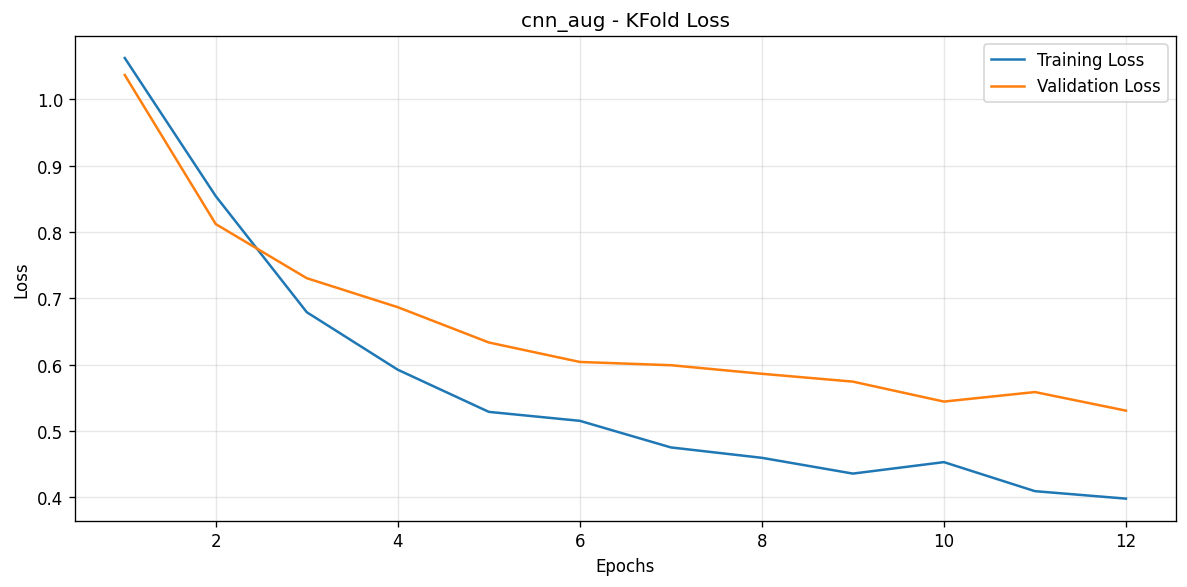

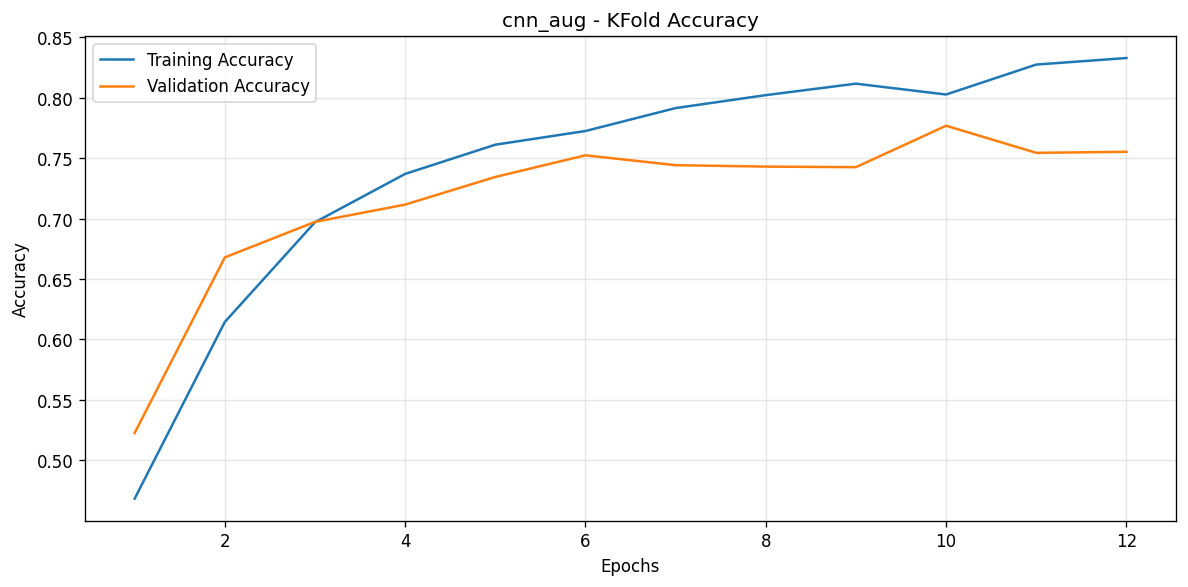

In [39]:
plot_kfold(
    aug_histories,
    title_prefix=cfg_aug["experiment_name"],
    save_paths=save_paths
)

In [40]:
with open(save_paths["kfold_metrics"], "w") as f:
    for row in aug_metrics:
        f.write(f"Fold {row['fold']}: val_acc={row['val_acc']:.4f}, val_loss={row['val_loss']:.4f}\n")

    f.write("\n")
    f.write(f"Mean val_acc: {np.mean(aug_accuracy):.4f}\n")
    f.write(f"Std val_acc : {np.std(aug_accuracy):.4f}\n")
    f.write(f"Mean val_loss: {np.mean(aug_losses):.4f}\n")
    f.write(f"Std val_loss : {np.std(aug_losses):.4f}\n")

In [41]:
del aug_metrics
del aug_histories
gc.collect()

14758

## Training + Evaluation

Using preprocessing: baseline
Using preprocessing: baseline
Epoch 1/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - accuracy: 0.4612 - loss: 1.0552 - val_accuracy: 0.5703 - val_loss: 1.0332
Epoch 2/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 177ms/step - accuracy: 0.6423 - loss: 0.8444 - val_accuracy: 0.6864 - val_loss: 0.8328
Epoch 3/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 180ms/step - accuracy: 0.6653 - loss: 0.7218 - val_accuracy: 0.7597 - val_loss: 0.7478
Epoch 4/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 178ms/step - accuracy: 0.7316 - loss: 0.6123 - val_accuracy: 0.7719 - val_loss: 0.6671
Epoch 5/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 175ms/step - accuracy: 0.7607 - loss: 0.5334 - val_accuracy: 0.7271 - val_loss: 0.6306
Epoch 6/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 173ms/step - accuracy: 0.7597 - loss: 0.5283 - val_accuracy: 0.8065 - val_loss: 0.6144
Epoch 7/30
62/62 ━━━━━━━━━━━━━━━━━━━━ 11s 172ms/step - accuracy: 0.7679 - loss: 0.5107 - val_accuracy: 0.7251 - val_loss: 0.5946
Epoch 8/30
62/62 ━━━━━━━━━━━━━━━━━━━━

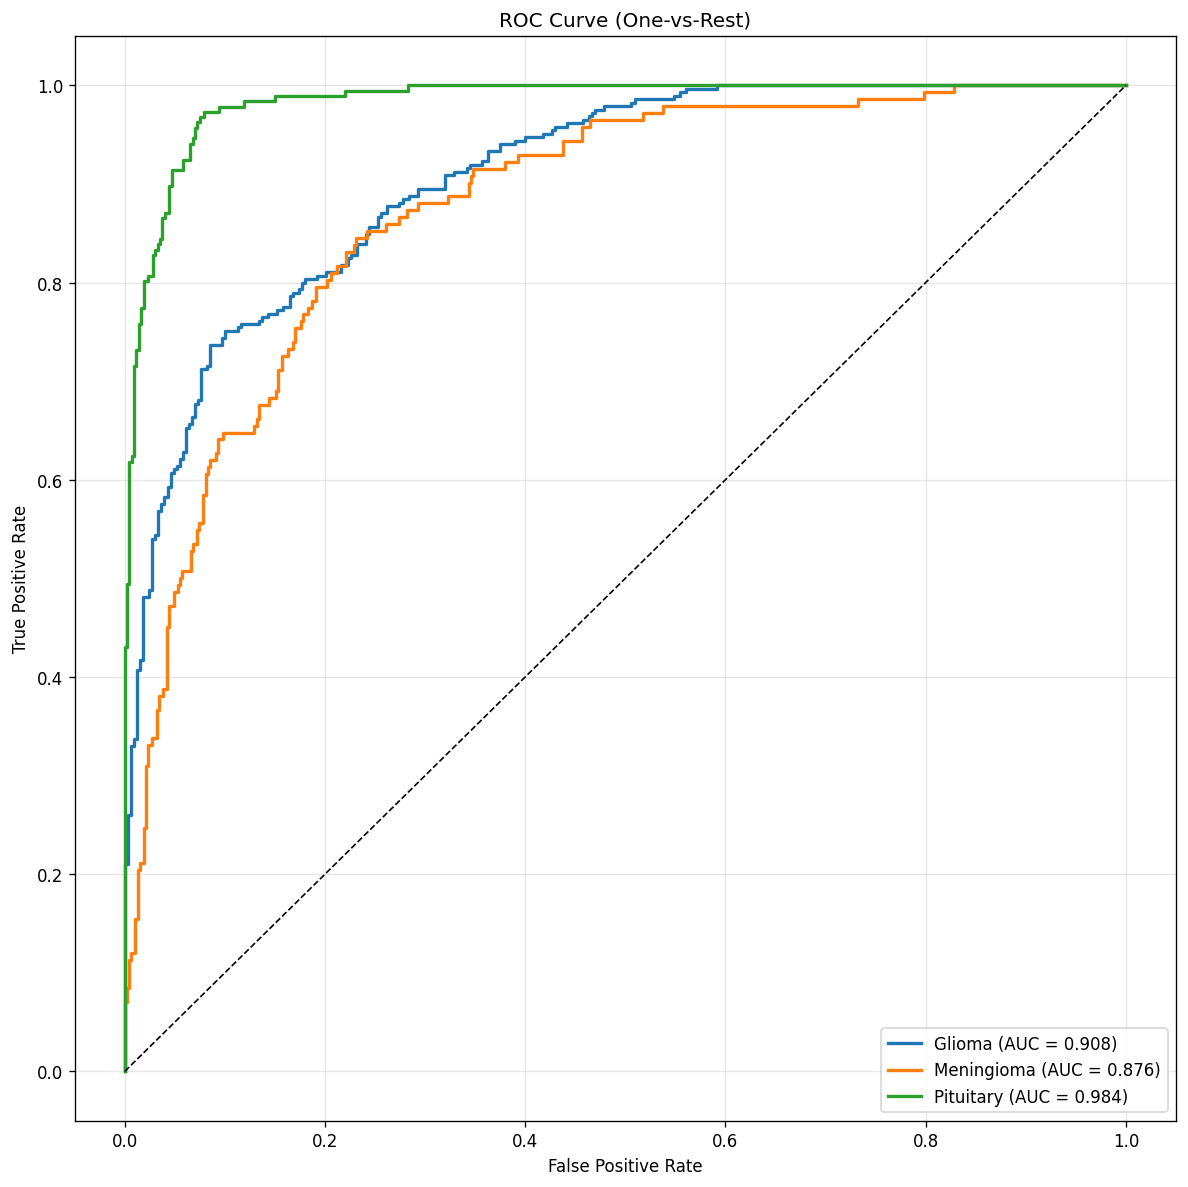


AUC per Class: 
Glioma: 0.9079
Meningioma: 0.8763
Pituitary: 0.9841
Macro AUC: 0.9228


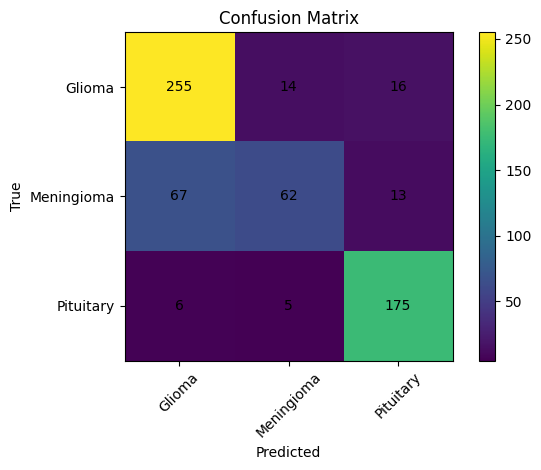

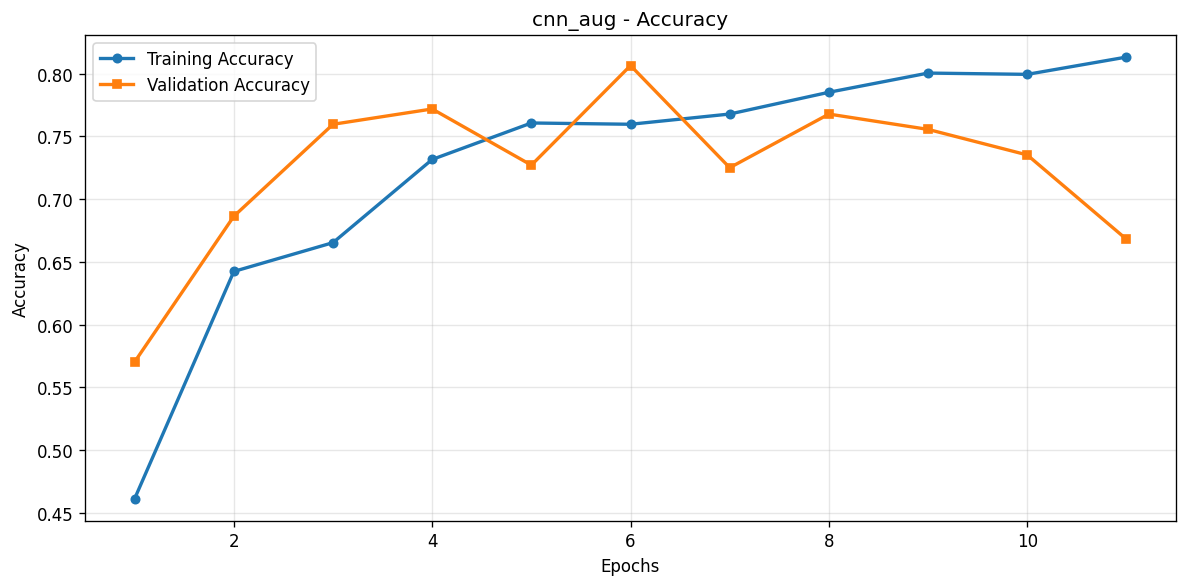

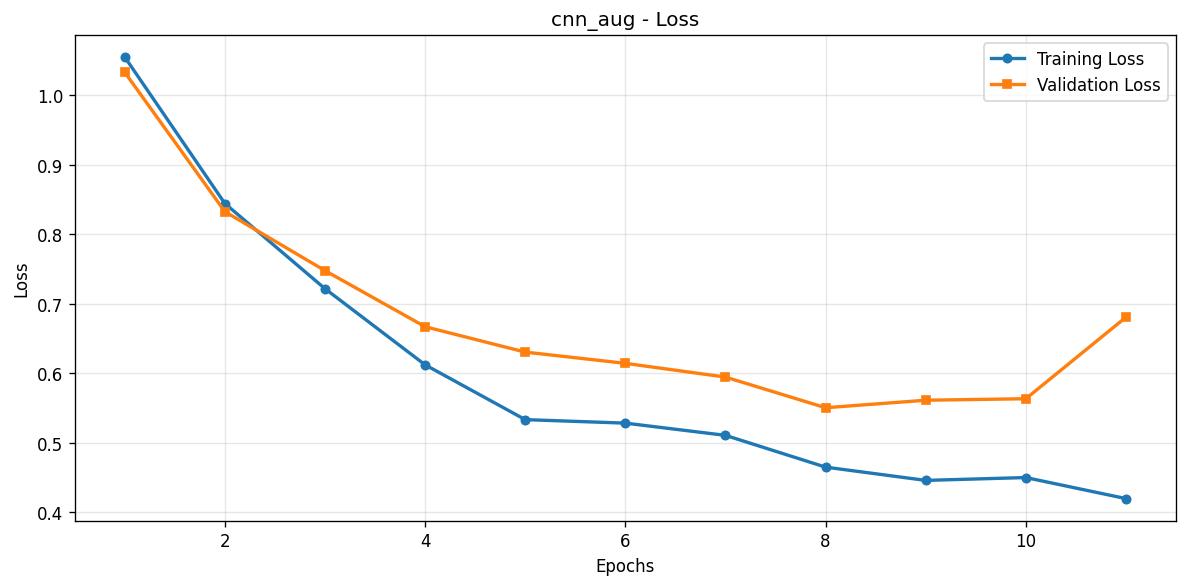

Loss:
  - loss [training dataset]: 0.420
  - loss [validation dataset]: 0.681

Accuracy:
  - accuracy [training dataset]: 81.33%
  - accuracy [validation dataset]: 66.80%


In [42]:
final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, roc_raw_data_path = train_test(
    cfg = cfg_aug,
    save_model = True
)

all_experiments["CNN Aug"] = {
    "macro_auc":    macro_auc,
    "roc_raw_data": roc_raw_data_path + ".npz"
}

In [43]:
del final_model, final_history, test_loss, test_accuracy, cm, report, roc_auc_dict, macro_auc, cfg_aug, save_paths, roc_raw_data_path
gc.collect()

9930

In [44]:
tf.keras.backend.clear_session()

## CNN Base Model vs CNN Base Model With Augmentation

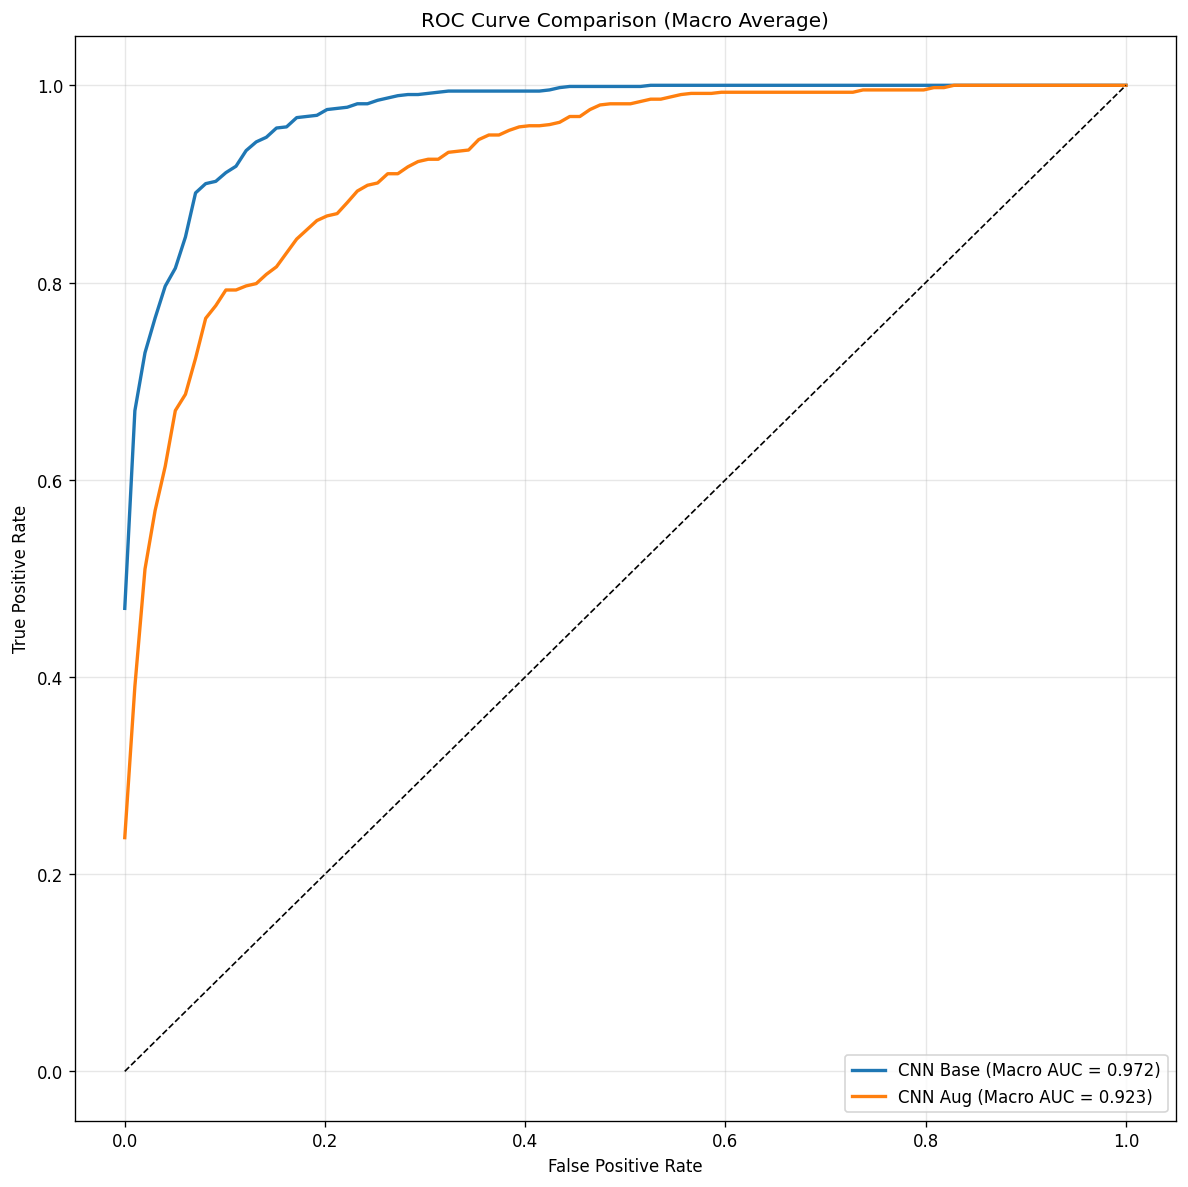

Best CNN experiment: CNN Base (Macro AUC = 0.972)
Saved to: /content/drive/MyDrive/Τμήμα Φυσικής ΑΠΘ - Προπτυχιακό/Πτυχιακή/Project για πτυχιακή εργασία/Code Για Πτυχιακή/CNN Model/cnn_experiments.pkl


In [45]:
# Combined ROC — CNN Base vs CNN Aug
plot_combined_roc(all_experiments, Class_Names, save_path=combined_roc_cnn_path)

# Εκτύπωση καλύτερου experiment
best_name, best_data = max(all_experiments.items(), key=lambda x: x[1]["macro_auc"])
print(f"Best CNN experiment: {best_name} (Macro AUC = {best_data['macro_auc']:.3f})")

with open(cnn_experiments_path, "wb") as f:
    pickle.dump(all_experiments, f)

print(f"Saved to: {cnn_experiments_path}")